In [ ]:
import glob
import os
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
# 1. 批量读取文件夹下的所有 CSV 文件
folder_path = r"F:\FusedTec\Data\Jason2021\TecCSV2_redisual_CH"  # 替换为你的 CSV 文件夹路径
all_files = glob.glob(os.path.join(folder_path, "*.csv"))
print("找到csv文件数量：", len(all_files))
df_list = []
for file in all_files:
    # 如果数据量极大，可使用 engine='pyarrow' 加快 CSV 读取速度
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

data = pd.concat(df_list, ignore_index=True)

找到csv文件数量： 9340


In [10]:
#2.查看数据类型
from pandas import set_option
from matplotlib import pyplot
# 数据维度
print('1.数据维度')
print(data.shape)

# 查看数据类型
# set_option('display.max_rows', 500)
print("2.数据类型")
print(data.dtypes)

1.数据维度
(1932268, 17)
2.数据类型
datetime        object
lat            float64
lon            float64
TEC_raw        float64
TEC_smooth     float64
alt            float64
gim_vtec       float64
residual       float64
HOD_s          float64
HOD_c          float64
DOY_s          float64
DOY_c          float64
f10.7_Index    float64
Dst_Index      float64
Kp_Index       float64
mag_lat        float64
mag_lon        float64
dtype: object


In [15]:
# 查看每一列空值数量
print("每列空值数量：")
print(data.isnull().sum())
data = data.dropna(axis=0, how='any')#去掉空值

每列空值数量：
datetime         0
lat              0
lon              0
TEC_raw          0
TEC_smooth       0
alt              0
gim_vtec         0
residual         0
HOD_s            0
HOD_c            0
DOY_s            0
DOY_c            0
f10.7_Index    205
Dst_Index      205
Kp_Index       205
mag_lat          0
mag_lon          0
dtype: int64


In [17]:
# 查看最初的20条记录
# set_option('display.width', 100)
print("3.查看前20条记录")
print(data.head(20))

# 描述性统计信息
# set_option('precision', 3)
print("4.查看统计信息")
print(data.describe())

3.查看前20条记录
                         datetime        lat         lon    TEC_raw  \
0   2021-01-01 00:32:55.906070272 -65.162744  132.875507  12.783294   
1   2021-01-01 00:33:45.313500416 -64.335547  138.508300   8.070851   
2   2021-01-01 00:33:54.991244032 -64.147324  139.568389   8.154685   
3   2021-01-01 00:34:04.668988672 -63.950767  140.613099   8.262905   
4   2021-01-01 00:34:14.856087040 -63.735294  141.696297   8.550987   
5   2021-01-01 00:34:25.043185920 -63.511167  142.762164   8.957959   
6   2021-01-01 00:34:35.230284544 -63.278601  143.810480   9.383223   
7   2021-01-01 00:34:44.908028416 -63.050111  144.790113   9.709409   
8   2021-01-01 00:34:54.585772032 -62.814261  145.753371   9.890794   
9   2021-01-01 00:35:04.772871168 -62.558457  146.750018   9.922803   
10  2021-01-01 00:35:14.959969792 -62.295061  147.728729   9.822203   
11  2021-01-01 00:35:25.147068928 -62.024288  148.689509   9.625576   
12  2021-01-01 00:35:35.334168064 -61.746348  149.632403   9.41523

In [19]:
# 优化
# 1.不显示错误警告
import warnings
warnings.filterwarnings('ignore')

# 2.画图过程中的中文显示
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows黑体，正常显示中文标题
plt.rcParams['axes.unicode_minus'] = False    # 【核心】修复负号不显示/变成方框

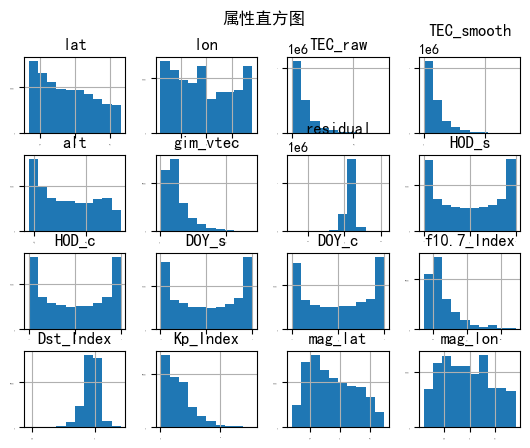

In [ ]:
# 直方图
data.hist(sharex=False, sharey=False,xlabelsize=1, ylabelsize=1)
pyplot.suptitle("属性直方图")
pyplot.show()

# 密度图
data.plot(kind='density', subplots=True, layout=(8,8), sharex=False, legend=False, fontsize=1)
pyplot.suptitle("属性密度图")
pyplot.show()

In [ ]:


import matplotlib.pyplot as plt

data_num = data.drop(columns=['datetime','TEC_raw','TEC_smooth'])
corr_mat = data_num.corr()

fig = plt.figure(figsize=(10,8))
fig.suptitle('关系矩阵图')
ax = fig.add_subplot(111)
cax = ax.matshow(corr_mat, vmin=-1, vmax=1, interpolation='none')
fig.colorbar(cax)

# 设置坐标轴标签
ax.set_xticks(range(len(corr_mat.columns)))
ax.set_yticks(range(len(corr_mat.columns)))
ax.set_xticklabels(corr_mat.columns, rotation=90)
ax.set_yticklabels(corr_mat.columns)

plt.show()

In [ ]:
#3.分离数据集，按照7：1：2，十折叠或者是留一分析
target_col = 'residual'
exclude_cols = ['datetime', 'residual', 'gim_vtec', 'TEC_smooth', 'TEC_raw']
feature_cols = [col for col in data.columns if col not in exclude_cols]

X = data[feature_cols]
y = data[target_col]
seed = 7 # 随机数种子，这里面的数字需要修改吗？
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed)
print("已经分好类")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from tqdm import tqdm  # 如果未安装，先在终端/Cell运行: !pip install tqdm

# 1. 算法评估配置
num_folds = 5
seed = 42

model_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1  # 充分利用多核 CPU
}

kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

# 初始化容器
rmse_results = []
y_pred_cv = np.zeros(len(y_train))  # 用于保存袋外(OOF)预测结果

# 转换为 numpy 数组以确保索引兼容（针对 Pandas DataFrame/Series）
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train

print("=== 开始 K 折交叉验证 ===")

# 2. 带 tqdm 进度条的单次 KFold 循环（避免 duplicate 训练，计算耗时直接减半）
fold_splits = list(kfold.split(X_train_np, y_train_np))
for fold, (train_idx, val_idx) in enumerate(tqdm(fold_splits, desc="Cross-Validation Progress")):
    X_tr, y_tr = X_train_np[train_idx], y_train_np[train_idx]
    X_va, y_va = X_train_np[val_idx], y_train_np[val_idx]
    
    # 构建并训练当前折的模型
    fold_model = xgb.XGBRegressor(**model_params)
    fold_model.fit(X_tr, y_tr)
    
    # 预测验证集
    preds = fold_model.predict(X_va)
    y_pred_cv[val_idx] = preds
    
    # 计算当前折 RMSE
    fold_rmse = np.sqrt(mean_squared_error(y_va, preds))
    rmse_results.append(fold_rmse)

rmse_results = np.array(rmse_results)
print(f"\n平均 RMSE: {rmse_results.mean():.6f} (标准差: {rmse_results.std():.6f})")

# 3. 绘制回归性能三合一图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图 1：真实值 vs 预测值散点图
ax1 = axes[0]
ax1.scatter(y_train, y_pred_cv, alpha=0.2, color='#1f77b4', s=12, label='Samples')
min_val = min(y_train.min(), y_pred_cv.min())
max_val = max(y_train.max(), y_pred_cv.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

r2_cv = r2_score(y_train, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y_train, y_pred_cv))
ax1.text(0.05, 0.85, f"$R^2$ = {r2_cv:.4f}\nRMSE = {rmse_cv:.4f}", 
         transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax1.set_xlabel('True Residual')
ax1.set_ylabel('Predicted Residual')
ax1.set_title('True vs. Predicted Value')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# 图 2：预测残差分布直方图
ax2 = axes[1]
errors = y_train_np - y_pred_cv
ax2.hist(errors, bins=40, color='#2ca02c', edgecolor='white', alpha=0.7, label='Error Dist')
ax2.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero Error')
ax2.set_xlabel('Prediction Error ($y_{true} - y_{pred}$)')
ax2.set_ylabel('Count')
ax2.set_title('Residual Error Distribution')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# 图 3：K 折 RMSE 柱状图
ax3 = axes[2]
folds = [f'Fold {i+1}' for i in range(num_folds)]
bars = ax3.bar(folds, rmse_results, color='#aec7e8', edgecolor='#1f77b4', width=0.5)
ax3.axhline(rmse_results.mean(), color='red', linestyle='--', label=f'Mean RMSE: {rmse_results.mean():.4f}')

for bar in bars:
    height = bar.get_height()
    ax3.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax3.set_ylabel('RMSE')
ax3.set_title('Cross-Validation RMSE by Fold')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6, axis='y')

plt.tight_layout()
plt.show()

# 4. 训练全量模型并绘制特征重要性排序图 (Top 10)
print("\n=== 正在训练全量数据模型 (用于特征重要性评估) ===")
final_model = xgb.XGBRegressor(**model_params)
final_model.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 5))
xgb.plot_importance(final_model, max_num_features=10, importance_type='weight', 
                   ax=ax, color='#ff7f0e', title='Top 10 Feature Importances')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()